# Predicting Customer Response to an Outreach Campaign

This notebook builds and compares models to predict `accepted_offer` for the midterm outreach campaign dataset. The workflow is organized to show the decisions behind the modeling pipeline, not just the final score.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42

# Works whether the notebook is run from the midterm folder or the repository root.
DATA_DIR = Path.cwd()
if not (DATA_DIR / "midterm_train.csv").exists():
    DATA_DIR = DATA_DIR / "midterm"

c:\Users\tyler\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
train = pd.read_csv(DATA_DIR / "midterm_train.csv")
test = pd.read_csv(DATA_DIR / "midterm_test.csv")
dictionary = pd.read_csv(DATA_DIR / "midterm_data_dictionary.csv")

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
display(dictionary)
display(train.head())

Train shape: (32950, 23)
Test shape:  (8238, 22)


,column_name,description,type
0,id,Internal record identifier for each observation.,identifier
1,customer_age,Age of the customer when the outreach event oc...,numeric
2,occupation_type,Work category associated with the customer.,categorical
3,relationship_status,Current household or partnership status.,categorical
4,education_background,Reported educational attainment category.,categorical
5,has_credit_issue,Indicator of prior credit repayment problems o...,categorical/binary
6,mortgage_status,Indicator showing whether the customer has a h...,categorical/binary
7,personal_loan_status,Indicator showing whether the customer has a p...,categorical/binary
8,last_contact_month,Calendar month of the most recent outreach att...,categorical
9,day_of_week,Weekday on which the most recent contact took ...,categorical


,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,...,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
0,12556,28,services,married,high.school,no,yes,no,jul,tue,...,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,0,0
1,35451,27,admin.,married,university.degree,no,yes,yes,jul,fri,...,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0,0,0
2,30592,43,self-employed,married,high.school,unknown,yes,no,apr,wed,...,0,nonexistent,-1.8,93.075,-47.1,1.498,5099.1,0,0,0
3,17914,43,admin.,single,university.degree,no,yes,no,aug,fri,...,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0,0
4,3315,41,admin.,married,unknown,no,no,no,sep,wed,...,3,success,-1.1,94.199,-37.5,0.886,4963.6,1,1,1


## Exploratory Data Analysis

I focus the EDA on class balance, suspicious/missing values, and features that may influence model design. The dataset uses the string `unknown` in several categorical fields and `999` in `days_since_prior_contact` to indicate no earlier contact.

In [3]:
target_rate = train["accepted_offer"].mean()
print(f"Accepted offer rate: {target_rate:.3%}")

overview = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing": train.isna().sum(),
    "missing_pct": train.isna().mean().mul(100).round(2),
    "n_unique": train.nunique(),
})
display(overview)

categorical_cols_eda = train.drop(columns=["accepted_offer", "id"]).select_dtypes(include="object").columns.tolist()
unknown_summary = (
    train[categorical_cols_eda]
    .eq("unknown")
    .sum()
    .sort_values(ascending=False)
    .to_frame("unknown_count")
)
unknown_summary["unknown_pct"] = (unknown_summary["unknown_count"] / len(train) * 100).round(2)
display(unknown_summary)

Accepted offer rate: 11.275%


,dtype,missing,missing_pct,n_unique
id,int64,0,0.0,32950
customer_age,int64,0,0.0,77
occupation_type,str,0,0.0,12
relationship_status,str,0,0.0,4
education_background,str,0,0.0,8
has_credit_issue,str,0,0.0,3
mortgage_status,str,0,0.0,3
personal_loan_status,str,0,0.0,3
last_contact_month,str,0,0.0,10
day_of_week,str,0,0.0,5


,unknown_count,unknown_pct
has_credit_issue,6858,20.81
education_background,1406,4.27
mortgage_status,786,2.39
personal_loan_status,786,2.39
occupation_type,262,0.80
relationship_status,68,0.21
last_contact_month,0,0.00
day_of_week,0,0.00
prior_outcome_status,0,0.00


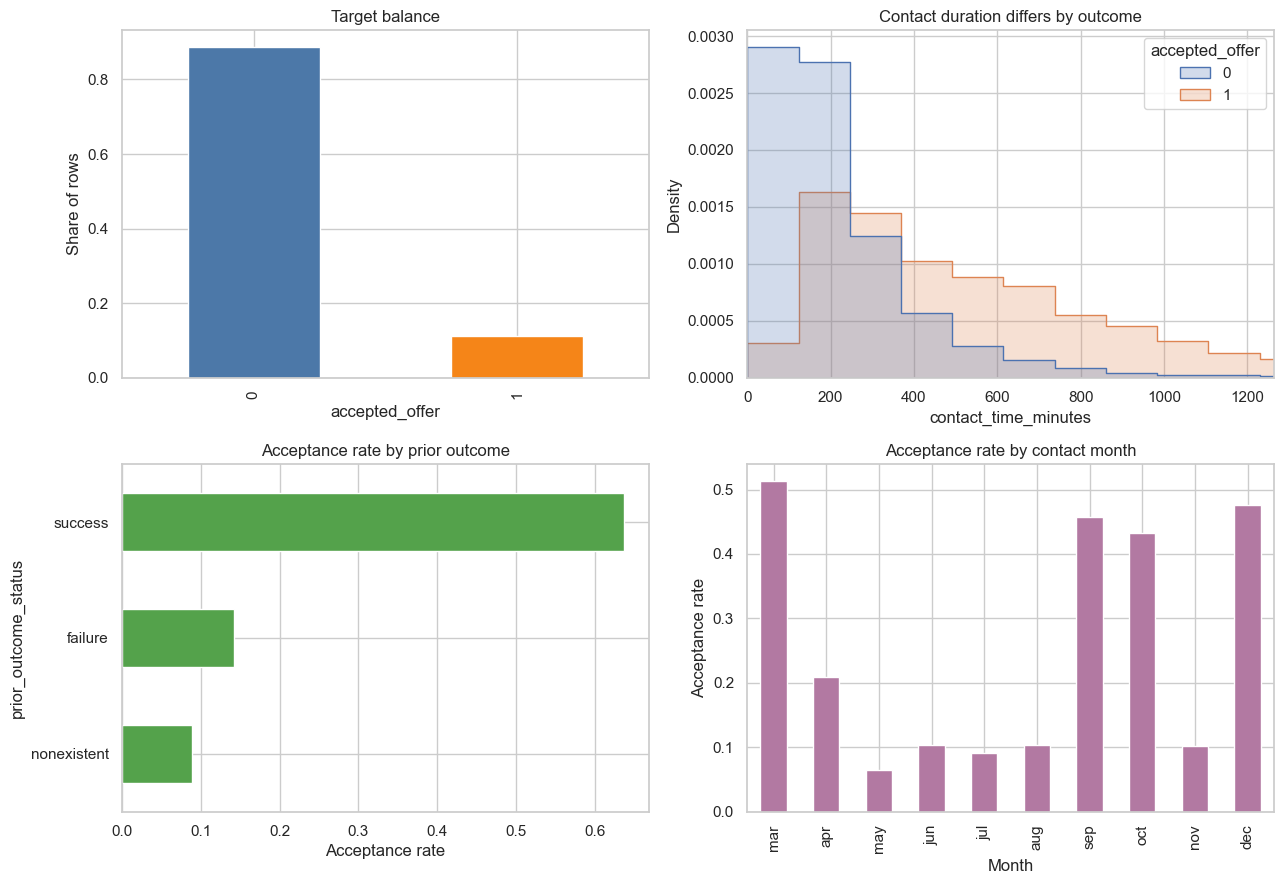

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

train["accepted_offer"].value_counts(normalize=True).sort_index().plot(
    kind="bar", ax=axes[0, 0], color=["#4C78A8", "#F58518"]
)
axes[0, 0].set_title("Target balance")
axes[0, 0].set_xlabel("accepted_offer")
axes[0, 0].set_ylabel("Share of rows")

sns.histplot(
    data=train,
    x="contact_time_minutes",
    hue="accepted_offer",
    bins=40,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Contact duration differs by outcome")
axes[0, 1].set_xlim(0, train["contact_time_minutes"].quantile(0.99))

prior_rates = train.groupby("prior_outcome_status")["accepted_offer"].mean().sort_values()
prior_rates.plot(kind="barh", ax=axes[1, 0], color="#54A24B")
axes[1, 0].set_title("Acceptance rate by prior outcome")
axes[1, 0].set_xlabel("Acceptance rate")

month_order = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
month_rates = train.groupby("last_contact_month")["accepted_offer"].mean().reindex(month_order).dropna()
month_rates.plot(kind="bar", ax=axes[1, 1], color="#B279A2")
axes[1, 1].set_title("Acceptance rate by contact month")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Acceptance rate")

plt.tight_layout()
plt.show()

In [5]:
numeric_cols_eda = train.drop(columns=["accepted_offer", "id"]).select_dtypes(include=np.number).columns.tolist()
corr_with_target = (
    train[numeric_cols_eda + ["accepted_offer"]]
    .corr(numeric_only=True)["accepted_offer"]
    .drop("accepted_offer")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("correlation_with_target")
)
display(corr_with_target)

,correlation_with_target
contact_time_minutes,0.404403
employment_level_index,-0.355823
days_since_prior_contact,-0.320040
recent_contact_flag,0.319990
reference_interest_rate,-0.308602
economic_activity_change,-0.298351
prior_contact_count,0.229570
is_repeat_customer,0.191969
consumer_price_index,-0.134264
contact_attempt_count,-0.065250


EDA takeaways:

- The positive class is a minority class, so stratified validation and metrics beyond accuracy are needed.
- `contact_time_minutes`, previous campaign outcome, and macroeconomic indicators look predictive.
- `days_since_prior_contact = 999` is a coded value, not a true duration, so I treat it explicitly during feature engineering.

## Data Preparation

The test set is held out for final predictions only. I split the labeled data into a training split for cross-validated tuning and a stratified validation split for apples-to-apples model comparison.

In [6]:
target = "accepted_offer"
id_col = "id"

X = train.drop(columns=[target])
y = train[target].astype(int)
X_test = test.copy()

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

base_feature_cols = [c for c in X.columns if c != id_col]
base_numeric_cols = X[base_feature_cols].select_dtypes(include=np.number).columns.tolist()
base_categorical_cols = X[base_feature_cols].select_dtypes(exclude=np.number).columns.tolist()

print(f"Training rows: {len(X_train):,}; validation rows: {len(X_valid):,}")
print("Numeric columns:", base_numeric_cols)
print("Categorical columns:", base_categorical_cols)

Training rows: 26,360; validation rows: 6,590
Numeric columns: ['customer_age', 'contact_time_minutes', 'contact_attempt_count', 'days_since_prior_contact', 'prior_contact_count', 'economic_activity_change', 'consumer_price_index', 'consumer_confidence_index', 'reference_interest_rate', 'employment_level_index', 'is_repeat_customer', 'recent_contact_flag']
Categorical columns: ['occupation_type', 'relationship_status', 'education_background', 'has_credit_issue', 'mortgage_status', 'personal_loan_status', 'last_contact_month', 'day_of_week', 'prior_outcome_status']


## Feature Engineering or Feature Selection

I compare a basic representation against a small engineered representation. The engineered version keeps the original business fields but adds a cleaner prior-contact signal and a log transform of call duration.

In [7]:
def add_campaign_features(df):
    """Add small, interpretable campaign features without using the target."""
    out = df.copy()
    no_prior = out["days_since_prior_contact"].eq(999)
    out["no_prior_contact"] = no_prior.astype(int)
    out["days_since_prior_contact_clean"] = out["days_since_prior_contact"].mask(no_prior, np.nan)
    out["contact_time_log1p"] = np.log1p(out["contact_time_minutes"].clip(lower=0))
    out["attempts_per_prior_contact"] = out["contact_attempt_count"] / (out["prior_contact_count"] + 1)
    return out


engineered_sample = add_campaign_features(X_train)
engineered_feature_cols = [c for c in engineered_sample.columns if c != id_col]
engineered_numeric_cols = engineered_sample[engineered_feature_cols].select_dtypes(include=np.number).columns.tolist()
engineered_categorical_cols = engineered_sample[engineered_feature_cols].select_dtypes(exclude=np.number).columns.tolist()


def make_preprocessor(numeric_cols, categorical_cols, scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipe = Pipeline(numeric_steps)
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipe, numeric_cols),
        ("categorical", categorical_pipe, categorical_cols),
    ])


def build_pipeline(model, engineered=False, scale_numeric=False):
    if engineered:
        return Pipeline([
            ("features", FunctionTransformer(add_campaign_features, validate=False)),
            ("preprocess", make_preprocessor(engineered_numeric_cols, engineered_categorical_cols, scale_numeric)),
            ("model", model),
        ])
    return Pipeline([
        ("preprocess", make_preprocessor(base_numeric_cols, base_categorical_cols, scale_numeric)),
        ("model", model),
    ])


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [8]:
feature_compare = []

for label, engineered in [
    ("Basic features", False),
    ("Engineered features", True),
]:
    pipe = build_pipeline(
        LogisticRegression(max_iter=2000, solver="liblinear", class_weight="balanced", random_state=RANDOM_STATE),
        engineered=engineered,
        scale_numeric=True,
    )
    scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_fold_train = X_train.iloc[train_idx]
        X_fold_valid = X_train.iloc[val_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_valid = y_train.iloc[val_idx]
        model = clone(pipe).fit(X_fold_train, y_fold_train)
        scores.append(roc_auc_score(y_fold_valid, model.predict_proba(X_fold_valid)[:, 1]))
    feature_compare.append({
        "feature_set": label,
        "mean_cv_roc_auc": np.mean(scores),
        "std_cv_roc_auc": np.std(scores),
    })

feature_compare = pd.DataFrame(feature_compare)
display(feature_compare)

,feature_set,mean_cv_roc_auc,std_cv_roc_auc
0,Basic features,0.936650,0.001243
1,Engineered features,0.938109,0.000911


## Modeling and Evaluation

I tune five model families that differ in meaningful ways:

- Regularized logistic regression: interpretable linear baseline.
- Extra Trees: nonlinear tree ensemble with bagging-style variance reduction.
- Histogram Gradient Boosting: scikit-learn boosting model that can capture nonlinear interactions.
- LightGBM: efficient gradient boosting with leaf-wise tree growth.
- CatBoost: ordered boosting designed to handle categorical-style tabular signal well.

Hyperparameters are tuned with stratified 3-fold CV on the training split. Final comparisons use the same untouched stratified validation split.

In [9]:
def evaluate_on_validation(name, fitted_model, threshold=0.5):
    valid_proba = fitted_model.predict_proba(X_valid)[:, 1]
    valid_pred = (valid_proba >= threshold).astype(int)
    return {
        "model": name,
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_valid, valid_proba),
        "accuracy": accuracy_score(y_valid, valid_pred),
        "balanced_accuracy": balanced_accuracy_score(y_valid, valid_pred),
        "f1": f1_score(y_valid, valid_pred),
        "precision": precision_score(y_valid, valid_pred, zero_division=0),
        "recall": recall_score(y_valid, valid_pred),
        "confusion_matrix": confusion_matrix(y_valid, valid_pred),
    }


tuned_models = {}
cv_results = []
validation_results = []

In [10]:
logistic_grid = GridSearchCV(
    estimator=build_pipeline(
        LogisticRegression(max_iter=2500, solver="liblinear", random_state=RANDOM_STATE),
        engineered=True,
        scale_numeric=True,
    ),
    param_grid={
        "model__C": [0.05, 0.1, 0.5, 1.0, 2.0],
        "model__penalty": ["l1", "l2"],
        "model__class_weight": [None, "balanced"],
    },
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)

logistic_grid.fit(X_train, y_train)
tuned_models["Logistic Regression"] = logistic_grid.best_estimator_
cv_results.append({
    "model": "Logistic Regression",
    "best_cv_roc_auc": logistic_grid.best_score_,
    "best_params": logistic_grid.best_params_,
})
validation_results.append(evaluate_on_validation("Logistic Regression", logistic_grid.best_estimator_))

display(pd.DataFrame(cv_results))

,model,best_cv_roc_auc,best_params
0,Logistic Regression,0.938145,"{'model__C': 0.5, 'model__class_weight': 'bala..."


In [11]:
extra_trees_search = RandomizedSearchCV(
    estimator=build_pipeline(
        ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        engineered=True,
        scale_numeric=False,
    ),
    param_distributions={
        "model__n_estimators": [250, 400],
        "model__max_depth": [None, 8, 14, 22],
        "model__min_samples_split": [2, 10, 25],
        "model__min_samples_leaf": [1, 3, 8],
        "model__max_features": ["sqrt", 0.5, None],
        "model__class_weight": [None, "balanced"],
    },
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

extra_trees_search.fit(X_train, y_train)
tuned_models["Extra Trees"] = extra_trees_search.best_estimator_
cv_results.append({
    "model": "Extra Trees",
    "best_cv_roc_auc": extra_trees_search.best_score_,
    "best_params": extra_trees_search.best_params_,
})
validation_results.append(evaluate_on_validation("Extra Trees", extra_trees_search.best_estimator_))

display(pd.DataFrame(cv_results))

,model,best_cv_roc_auc,best_params
0,Logistic Regression,0.938145,"{'model__C': 0.5, 'model__class_weight': 'bala..."
1,Extra Trees,0.945896,"{'model__n_estimators': 250, 'model__min_sampl..."


In [12]:
hgb_search = RandomizedSearchCV(
    estimator=build_pipeline(
        HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        engineered=True,
        scale_numeric=False,
    ),
    param_distributions={
        "model__learning_rate": [0.03, 0.05, 0.08, 0.12],
        "model__max_iter": [150, 250],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__min_samples_leaf": [20, 50, 100],
        "model__l2_regularization": [0.0, 0.05, 0.2],
    },
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

hgb_search.fit(X_train, y_train)
tuned_models["Hist Gradient Boosting"] = hgb_search.best_estimator_
cv_results.append({
    "model": "Hist Gradient Boosting",
    "best_cv_roc_auc": hgb_search.best_score_,
    "best_params": hgb_search.best_params_,
})
validation_results.append(evaluate_on_validation("Hist Gradient Boosting", hgb_search.best_estimator_))

display(pd.DataFrame(cv_results))

,model,best_cv_roc_auc,best_params
0,Logistic Regression,0.938145,"{'model__C': 0.5, 'model__class_weight': 'bala..."
1,Extra Trees,0.945896,"{'model__n_estimators': 250, 'model__min_sampl..."
2,Hist Gradient Boosting,0.948535,"{'model__min_samples_leaf': 20, 'model__max_le..."


In [13]:
lightgbm_search = RandomizedSearchCV(
    estimator=build_pipeline(
        LGBMClassifier(
            objective="binary",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        ),
        engineered=True,
        scale_numeric=False,
    ),
    param_distributions={
        "model__n_estimators": [200, 350, 500],
        "model__learning_rate": [0.02, 0.04, 0.07, 0.10],
        "model__num_leaves": [15, 31, 63],
        "model__max_depth": [-1, 4, 8, 12],
        "model__min_child_samples": [20, 50, 100],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0],
        "model__reg_lambda": [0.0, 0.5, 1.0],
    },
    n_iter=8,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

lightgbm_search.fit(X_train, y_train)
tuned_models["LightGBM"] = lightgbm_search.best_estimator_
cv_results.append({
    "model": "LightGBM",
    "best_cv_roc_auc": lightgbm_search.best_score_,
    "best_params": lightgbm_search.best_params_,
})
validation_results.append(evaluate_on_validation("LightGBM", lightgbm_search.best_estimator_))

display(pd.DataFrame(cv_results))

,model,best_cv_roc_auc,best_params
0,Logistic Regression,0.938145,"{'model__C': 0.5, 'model__class_weight': 'bala..."
1,Extra Trees,0.945896,"{'model__n_estimators': 250, 'model__min_sampl..."
2,Hist Gradient Boosting,0.948535,"{'model__min_samples_leaf': 20, 'model__max_le..."
3,LightGBM,0.948553,"{'model__subsample': 0.8, 'model__reg_lambda':..."


In [14]:
catboost_search = RandomizedSearchCV(
    estimator=build_pipeline(
        CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            bootstrap_type="Bernoulli",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
            thread_count=-1,
        ),
        engineered=True,
        scale_numeric=False,
    ),
    param_distributions={
        "model__iterations": [200, 350, 500],
        "model__learning_rate": [0.03, 0.05, 0.08, 0.12],
        "model__depth": [4, 6, 8],
        "model__l2_leaf_reg": [1, 3, 7, 10],
        "model__subsample": [0.8, 1.0],
    },
    n_iter=8,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

catboost_search.fit(X_train, y_train)
tuned_models["CatBoost"] = catboost_search.best_estimator_
cv_results.append({
    "model": "CatBoost",
    "best_cv_roc_auc": catboost_search.best_score_,
    "best_params": catboost_search.best_params_,
})
validation_results.append(evaluate_on_validation("CatBoost", catboost_search.best_estimator_))

display(pd.DataFrame(cv_results))

,model,best_cv_roc_auc,best_params
0,Logistic Regression,0.938145,"{'model__C': 0.5, 'model__class_weight': 'bala..."
1,Extra Trees,0.945896,"{'model__n_estimators': 250, 'model__min_sampl..."
2,Hist Gradient Boosting,0.948535,"{'model__min_samples_leaf': 20, 'model__max_le..."
3,LightGBM,0.948553,"{'model__subsample': 0.8, 'model__reg_lambda':..."
4,CatBoost,0.948298,"{'model__subsample': 1.0, 'model__learning_rat..."


In [15]:
validation_table = pd.DataFrame(validation_results).drop(columns=["confusion_matrix"])
validation_table = validation_table.sort_values("roc_auc", ascending=False)
display(validation_table)

for result in validation_results:
    print(f"\n{result['model']} confusion matrix at threshold {result['threshold']:.2f}")
    display(pd.DataFrame(
        result["confusion_matrix"],
        index=["actual_0", "actual_1"],
        columns=["pred_0", "pred_1"],
    ))

,model,threshold,roc_auc,accuracy,balanced_accuracy,f1,precision,recall
3,LightGBM,0.5,0.948913,0.911988,0.752437,0.583333,0.625578,0.546433
2,Hist Gradient Boosting,0.5,0.947939,0.910470,0.747470,0.574928,0.618605,0.537012
4,CatBoost,0.5,0.946244,0.910926,0.735977,0.563569,0.629568,0.510094
1,Extra Trees,0.5,0.944283,0.909256,0.742673,0.567294,0.613459,0.527591
0,Logistic Regression,0.5,0.937693,0.856146,0.875463,0.585302,0.433571,0.900404



Logistic Regression confusion matrix at threshold 0.50


,pred_0,pred_1
actual_0,4973,874
actual_1,74,669



Extra Trees confusion matrix at threshold 0.50


,pred_0,pred_1
actual_0,5600,247
actual_1,351,392


...

,pred_0,pred_1
actual_0,5601,246
actual_1,344,399



LightGBM confusion matrix at threshold 0.50


,pred_0,pred_1
actual_0,5604,243
actual_1,337,406



CatBoost confusion matrix at threshold 0.50


,pred_0,pred_1
actual_0,5624,223
actual_1,364,379


## Ensembling

The ensemble combines the tuned linear, bagged-tree, scikit-learn boosting, LightGBM, and CatBoost models with soft voting. This tests whether different model families capture complementary signal.

In [16]:
ensemble = VotingClassifier(
    estimators=[
        ("logistic", tuned_models["Logistic Regression"]),
        ("extra_trees", tuned_models["Extra Trees"]),
        ("hgb", tuned_models["Hist Gradient Boosting"]),
        ("lightgbm", tuned_models["LightGBM"]),
        ("catboost", tuned_models["CatBoost"]),
    ],
    voting="soft",
    weights=[1, 1, 2, 2, 2],
    n_jobs=1,
)
ensemble.fit(X_train, y_train)
tuned_models["Soft Voting Ensemble"] = ensemble
validation_results.append(evaluate_on_validation("Soft Voting Ensemble", ensemble))

validation_table = pd.DataFrame(validation_results).drop(columns=["confusion_matrix"])
validation_table = validation_table.sort_values("roc_auc", ascending=False)
display(validation_table)

,model,threshold,roc_auc,accuracy,balanced_accuracy,f1,precision,recall
3,LightGBM,0.5,0.948913,0.911988,0.752437,0.583333,0.625578,0.546433
5,Soft Voting Ensemble,0.5,0.948322,0.910926,0.772986,0.600952,0.607143,0.594886
2,Hist Gradient Boosting,0.5,0.947939,0.910470,0.747470,0.574928,0.618605,0.537012
4,CatBoost,0.5,0.946244,0.910926,0.735977,0.563569,0.629568,0.510094
1,Extra Trees,0.5,0.944283,0.909256,0.742673,0.567294,0.613459,0.527591
0,Logistic Regression,0.5,0.937693,0.856146,0.875463,0.585302,0.433571,0.900404


## Results Summary

The table below summarizes the models evaluated. I use validation ROC AUC as the primary ranking metric because the positive class is relatively uncommon and probability ranking is important. I also report F1 and balanced accuracy because the final deliverable requires hard `0/1` labels.

In [17]:
results_summary = validation_table.copy()
results_summary["preprocessing_or_features"] = "Median/mode imputation, one-hot categoricals, engineered prior-contact and contact-duration features"
results_summary["validation_method"] = "3-fold stratified CV for tuning, 20% stratified holdout for model comparison"
results_summary["primary_metric"] = "ROC AUC"
results_summary["brief_reason"] = np.where(
    results_summary["model"].eq(results_summary.iloc[0]["model"]),
    "Best validation ROC AUC among evaluated models",
    "Competitive benchmark, but not selected as final",
)

display(results_summary[[
    "model",
    "preprocessing_or_features",
    "validation_method",
    "primary_metric",
    "roc_auc",
    "balanced_accuracy",
    "f1",
    "accuracy",
    "brief_reason",
]])

,model,preprocessing_or_features,validation_method,primary_metric,roc_auc,balanced_accuracy,f1,accuracy,brief_reason
3,LightGBM,"Median/mode imputation, one-hot categoricals, ...","3-fold stratified CV for tuning, 20% stratifie...",ROC AUC,0.948913,0.752437,0.583333,0.911988,Best validation ROC AUC among evaluated models
5,Soft Voting Ensemble,"Median/mode imputation, one-hot categoricals, ...","3-fold stratified CV for tuning, 20% stratifie...",ROC AUC,0.948322,0.772986,0.600952,0.910926,"Competitive benchmark, but not selected as final"
2,Hist Gradient Boosting,"Median/mode imputation, one-hot categoricals, ...","3-fold stratified CV for tuning, 20% stratifie...",ROC AUC,0.947939,0.747470,0.574928,0.910470,"Competitive benchmark, but not selected as final"
4,CatBoost,"Median/mode imputation, one-hot categoricals, ...","3-fold stratified CV for tuning, 20% stratifie...",ROC AUC,0.946244,0.735977,0.563569,0.910926,"Competitive benchmark, but not selected as final"
1,Extra Trees,"Median/mode imputation, one-hot categoricals, ...","3-fold stratified CV for tuning, 20% stratifie...",ROC AUC,0.944283,0.742673,0.567294,0.909256,"Competitive benchmark, but not selected as final"
0,Logistic Regression,"Median/mode imputation, one-hot categoricals, ...","3-fold stratified CV for tuning, 20% stratifie...",ROC AUC,0.937693,0.875463,0.585302,0.856146,"Competitive benchmark, but not selected as final"


In [18]:
final_model_name = results_summary.iloc[0]["model"]
final_model = tuned_models[final_model_name]

# Choose a classification threshold using validation data only.
valid_proba = final_model.predict_proba(X_valid)[:, 1]
thresholds = np.linspace(0.05, 0.95, 181)
threshold_scores = pd.DataFrame({
    "threshold": thresholds,
    "f1": [f1_score(y_valid, valid_proba >= t) for t in thresholds],
    "balanced_accuracy": [balanced_accuracy_score(y_valid, valid_proba >= t) for t in thresholds],
})
best_threshold = threshold_scores.sort_values(["f1", "balanced_accuracy"], ascending=False).iloc[0]["threshold"]

print(f"Final model: {final_model_name}")
print(f"Validation-selected threshold for hard labels: {best_threshold:.3f}")
display(threshold_scores.sort_values("f1", ascending=False).head(10))

Final model: LightGBM
Validation-selected threshold for hard labels: 0.270


,threshold,f1,balanced_accuracy
44,0.270,0.647799,0.869105
43,0.265,0.646906,0.870857
42,0.260,0.646663,0.872277
47,0.285,0.645401,0.863071
41,0.255,0.645394,0.872939
51,0.305,0.645301,0.856632
49,0.295,0.644779,0.858970
50,0.300,0.643976,0.857294
40,0.250,0.643772,0.873013
46,0.280,0.643727,0.863146


## Final Model and Predictions

I now refit the selected model on all labeled training data and create the required `id,prediction` CSV for the test set. The test set is not used for tuning or model selection.

In [19]:
final_model_refit = clone(final_model)
final_model_refit.fit(X, y)

test_proba = final_model_refit.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

submission = pd.DataFrame({
    "id": X_test[id_col].astype(int),
    "prediction": test_pred.astype(int),
})

output_path = DATA_DIR / "roberts_tyler_predictions.csv"
submission.to_csv(output_path, index=False)

print(f"Saved {output_path} with shape {submission.shape}")
display(submission.head())
display(submission["prediction"].value_counts(normalize=True).rename("prediction_share").to_frame())

Saved c:\Users\tyler\OneDrive\Desktop\Advanced Machine Learning\midterm\roberts_tyler_predictions.csv with shape (8238, 2)


,id,prediction
0,32884,0
1,3169,1
2,32206,1
3,9403,0
4,14020,0


,prediction_share
prediction,
0,0.832848
1,0.167152
